In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

%matplotlib inline

df = pd.read_csv('customer_shopping_behavior.csv')
df = df.rename(columns={
    'Purchase Amount (USD)': 'Purchase_Amount',
    'Review Rating'        : 'Review_Rating',
    'Previous Purchases'   : 'Previous_Purchases'
})

print('Ready to plot!')

Ready to plot!


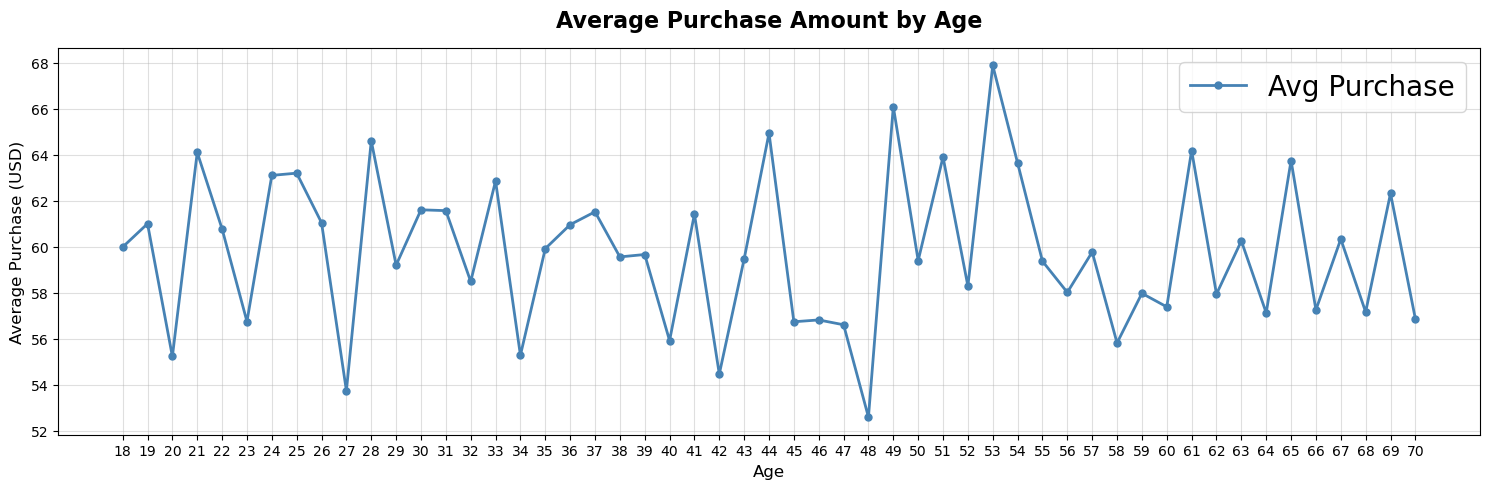

In [21]:
age_purchase = df.groupby('Age')['Purchase_Amount'].mean()

fig, ax = plt.subplots(figsize=(15, 5))      

ax.plot(
    age_purchase.index,                        
    age_purchase.values,                       
    color='steelblue',                         
    linewidth=2,                               
    marker='o',                                
    markersize=5,                              
    label='Avg Purchase'                      
)

ax.set_title('Average Purchase Amount by Age', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Age', fontsize=12)
ax.set_ylabel('Average Purchase (USD)', fontsize=12)
ax.legend(fontsize=20)                         
ax.set_xticks(age_purchase.index)

ax.grid(True, which='major', alpha=0.4)

plt.tight_layout()

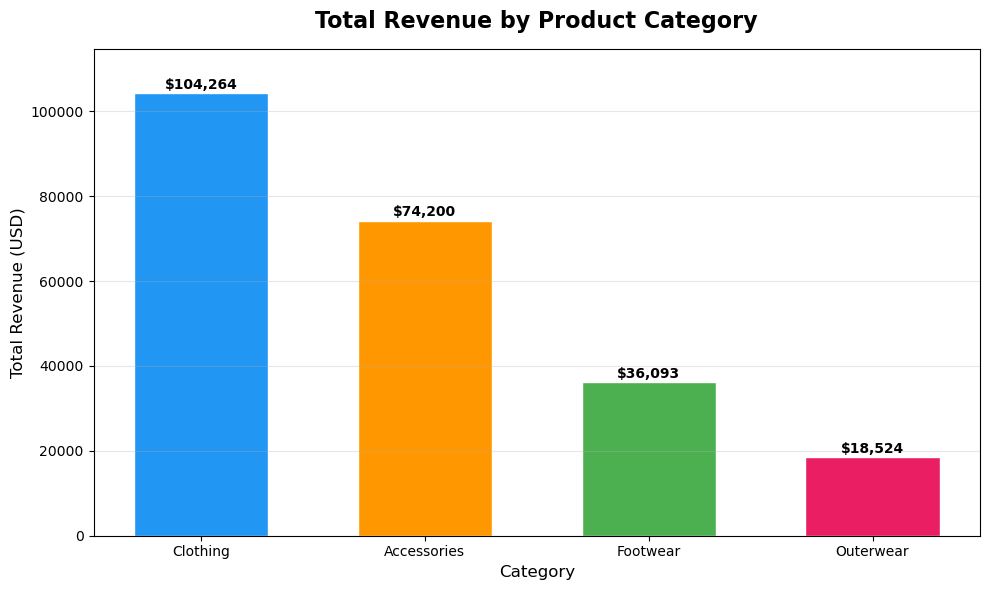

In [19]:
cat_revenue = df.groupby('Category')['Purchase_Amount'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    cat_revenue.index,                         
    cat_revenue.values,                        
    color=['#2196F3', '#FF9800', '#4CAF50', '#E91E63'],  
    edgecolor='white',
    linewidth=1,
    width=0.6
)


for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,    
        height + 1000,                          
        f'${height:,.0f}',                     
        ha='center', fontsize=10, fontweight='bold'
    )
    
ax.set_title('Total Revenue by Product Category', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Category', fontsize=12)
ax.set_ylabel('Total Revenue (USD)', fontsize=12)
ax.set_ylim(0, cat_revenue.max() * 1.1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

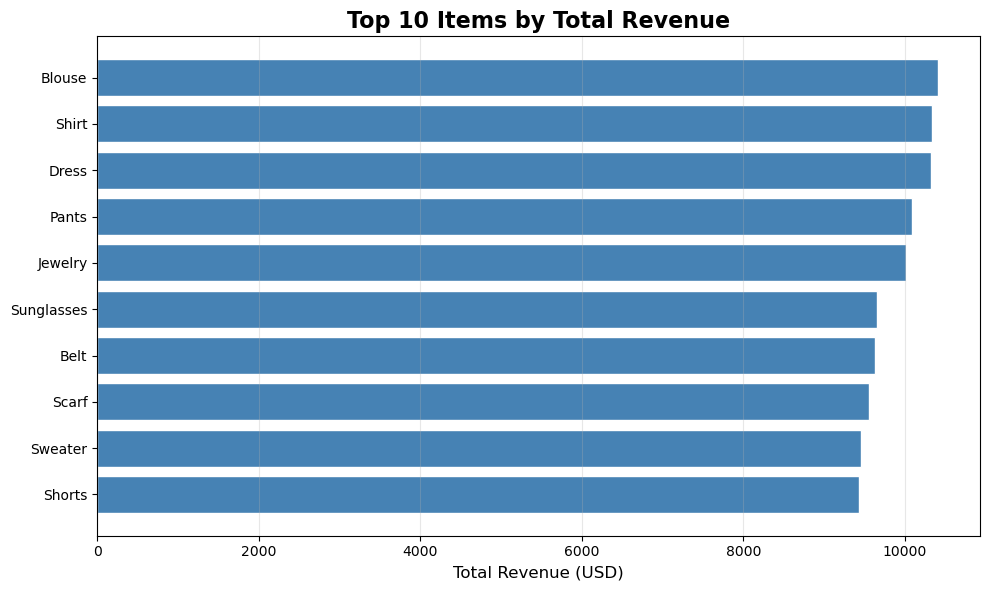

In [9]:
top_items = df.groupby('Item Purchased')['Purchase_Amount'].sum().sort_values().tail(10)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(top_items.index, top_items.values, color='steelblue', edgecolor='white')

ax.set_title('Top 10 Items by Total Revenue', fontsize=16, fontweight='bold')
ax.set_xlabel('Total Revenue (USD)', fontsize=12)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

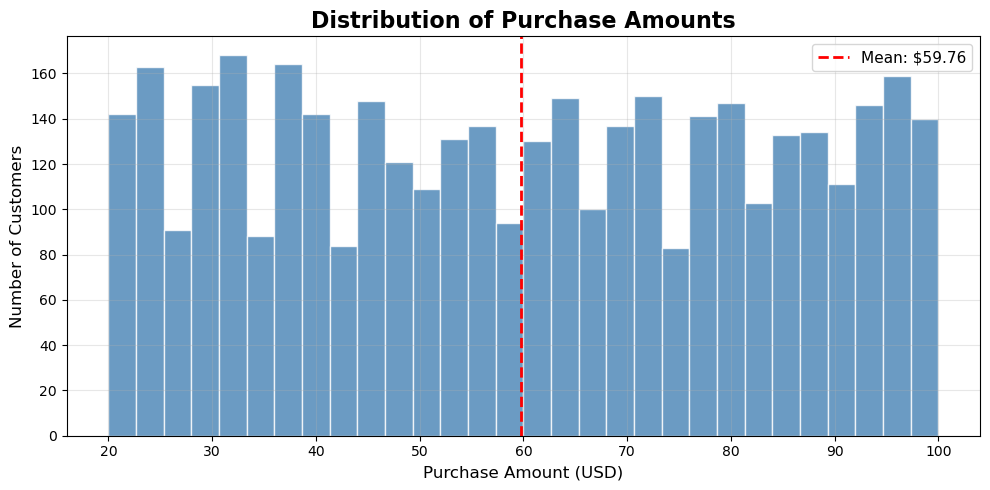

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    df['Purchase_Amount'],
    bins=30,                                   
    color='steelblue',
    edgecolor='white',
    alpha=0.8                                  
)

mean_val = df['Purchase_Amount'].mean()
ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: ${mean_val:.2f}')

ax.set_title('Distribution of Purchase Amounts', fontsize=16, fontweight='bold')
ax.set_xlabel('Purchase Amount (USD)', fontsize=12)
ax.set_ylabel('Number of Customers', fontsize=12)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

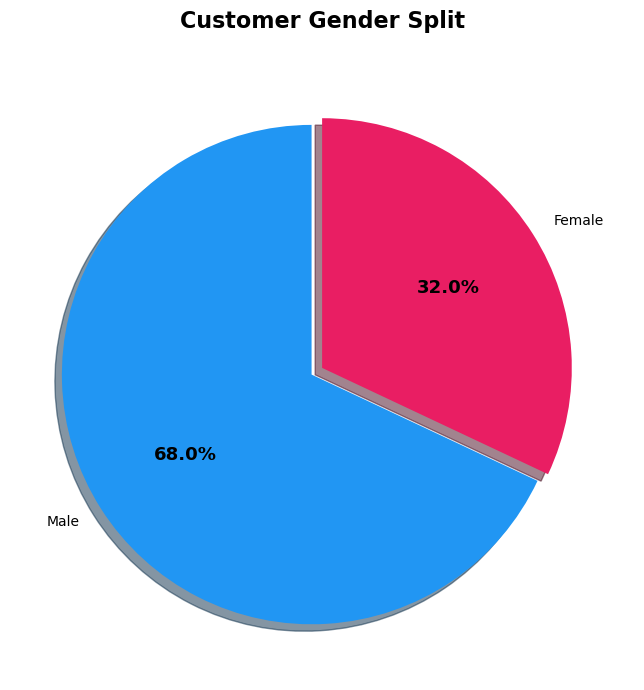

In [29]:
gender_counts = df['Gender'].value_counts()

fig, ax = plt.subplots(figsize=(7, 7))

wedges, texts, autotexts = ax.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct='%1.1f%%',                         
    colors=['#2196F3', '#E91E63'],
    explode=[0.05, 0],                         
    startangle=90,
    shadow=True
)

# Make percentage text bold
for autotext in autotexts:
    autotext.set_fontweight('bold')
    autotext.set_fontsize(13)

ax.set_title('Customer Gender Split', fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

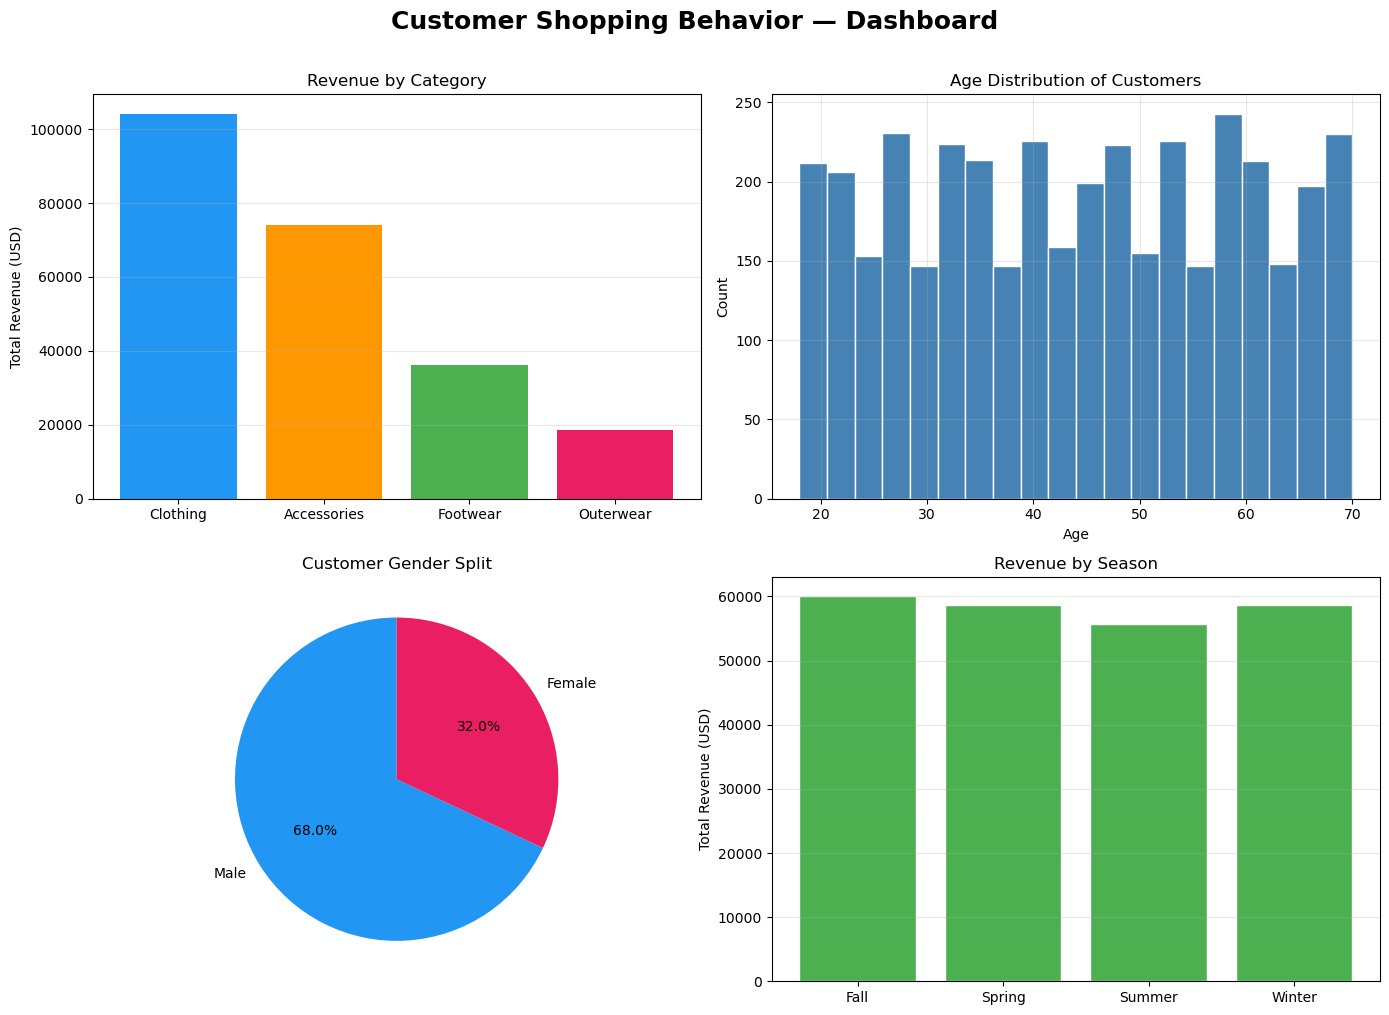

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Customer Shopping Behavior — Dashboard', fontsize=18, fontweight='bold', y=1.01)

#bar graph
cat_rev = df.groupby('Category')['Purchase_Amount'].sum().sort_values(ascending=False)
axes[0, 0].bar(cat_rev.index, cat_rev.values, color=['#2196F3','#FF9800','#4CAF50','#E91E63'])
axes[0, 0].set_title('Revenue by Category')
axes[0, 0].set_ylabel('Total Revenue (USD)')
axes[0, 0].grid(axis='y', alpha=0.3)

#histogram
axes[0, 1].hist(df['Age'], bins=20, color='steelblue', edgecolor='white')
axes[0, 1].set_title('Age Distribution of Customers')
axes[0, 1].set_xlabel('Age')
axes[0, 1].set_ylabel('Count')
axes[0, 1].grid(alpha=0.3)

#pie chart
gender_counts = df['Gender'].value_counts()
axes[1, 0].pie(gender_counts.values, labels=gender_counts.index,
               autopct='%1.1f%%', colors=['#2196F3', '#E91E63'], startangle=90)
axes[1, 0].set_title('Customer Gender Split')

#season bar graph
season_rev = df.groupby('Season')['Purchase_Amount'].sum()
axes[1, 1].bar(season_rev.index, season_rev.values, color='#4CAF50', edgecolor='white')
axes[1, 1].set_title('Revenue by Season')
axes[1, 1].set_ylabel('Total Revenue (USD)')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('dashboard.png', dpi=150, bbox_inches='tight')  # save as image!
plt.show()